In [315]:
import pyepo
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch import nn
import pandas as pd

In [306]:
def plot2D(x, y, xlbl, ylbl, title=None, regression=None):
    plt.scatter(x,y, c='gray')
    if regression is not None:
        x_line = np.array([min(x), max(x)])
        for line in regression: 
            y_line = line['weights'] * x_line + line['bias']
            plt.plot(x_line, y_line, label=line['type'])
    plt.legend()
    plt.xlabel(xlbl)
    plt.ylabel(ylbl)
    plt.title(title)
    plt.show()

In [263]:
#Parameters
i = 10 #items
n = 1000 #samples of data
d = 1 #numper of features
p = 1 #power of polynomial cost function
ec = 1 #noise multiplier for generating costs
ew = 1 #noise multiplied for generating weights
capPCT = 0.4 #capacity of knapsack as a % of total weight

#Generate Random Features
x = 10 * torch.rand((d,n))
#Generate Random Mapping
A = torch.randn((i,d))
#Generate Costs
c = (A @ x) ** p 
#Add Noise to Costs
c += ec * (torch.mean(c, dim=1, keepdim=True) * torch.rand(i,1) * torch.randn_like(c))
#Shift Values to have minimum at zero
c -= torch.min(c, dim=1, keepdim=True).values
#Generate Weights
w = torch.mean(c, dim=1) + (ew * torch.std(c, dim=1) * torch.randn(i))
w -= torch.min(w) - 1
#Calculate capacity
capacity = [int(torch.sum(w) * capPCT)]

In [264]:
print(f'Avg. Stdev. of Cost to Weight: {torch.mean(torch.std(c / w.unsqueeze(1), dim=0)):.2f}')

Avg. Stdev. of Cost to Weight: 0.39


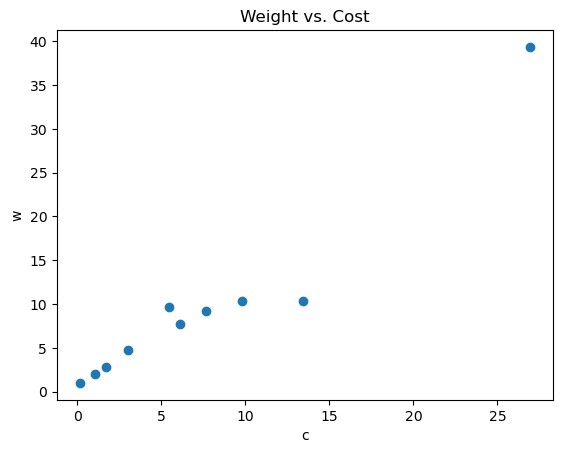

In [265]:
plot2D(torch.mean(c, dim=1), w, 'c', 'w', 'Weight vs. Cost')

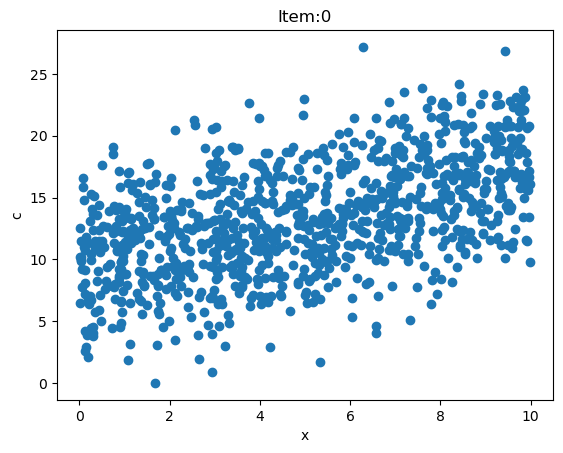

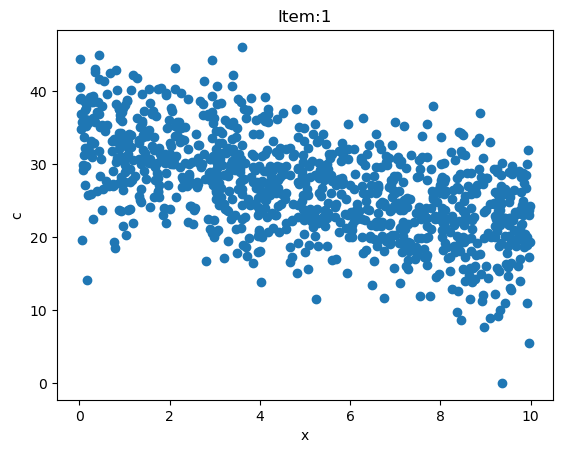

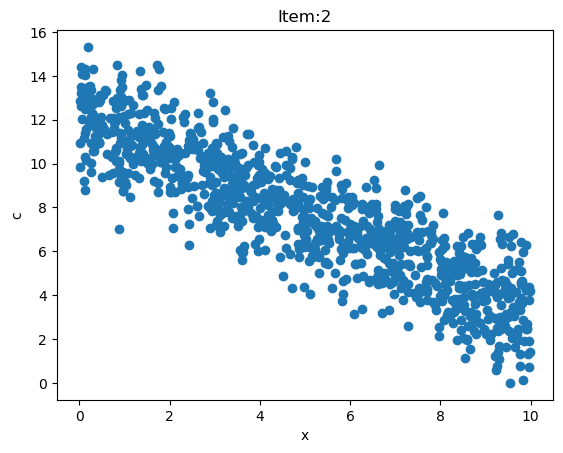

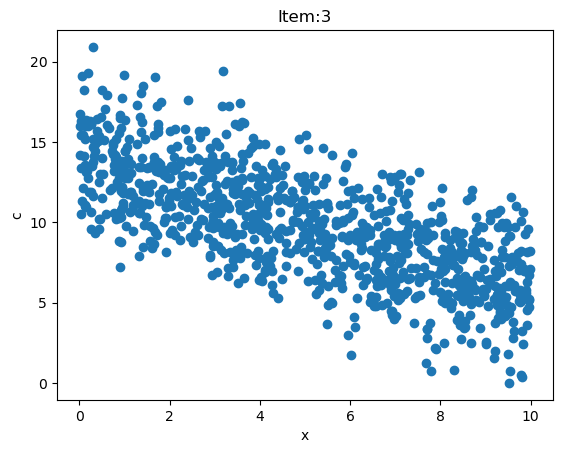

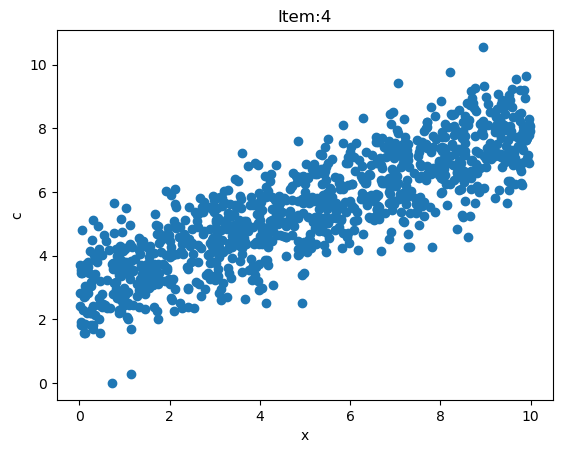

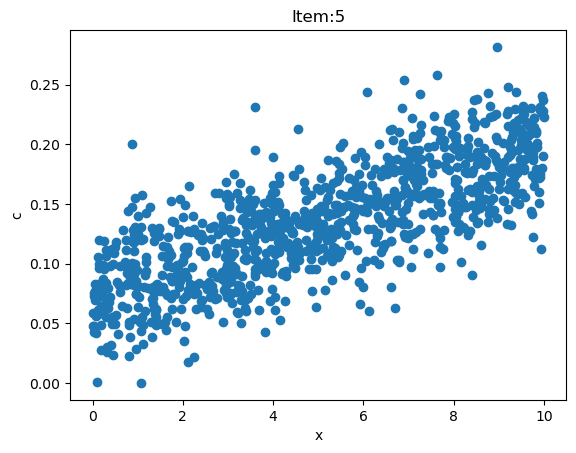

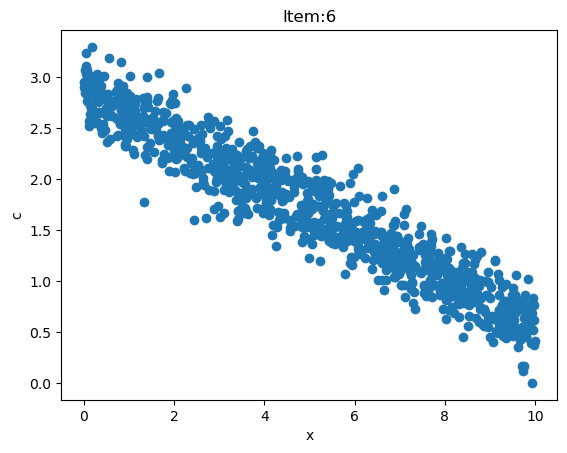

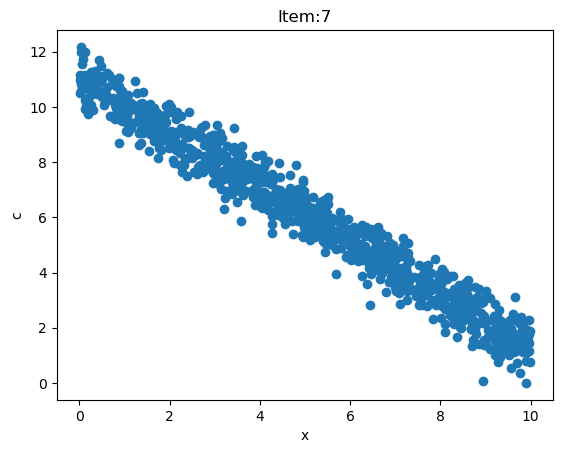

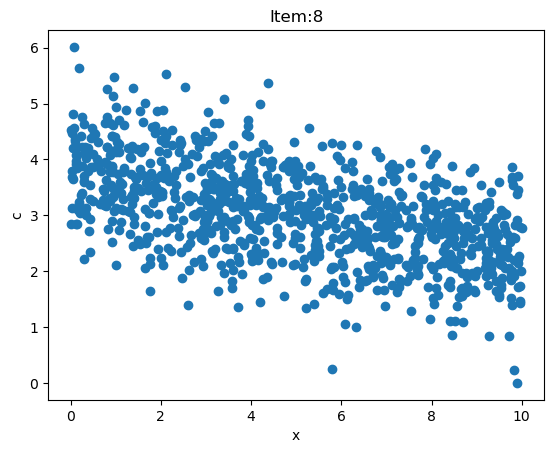

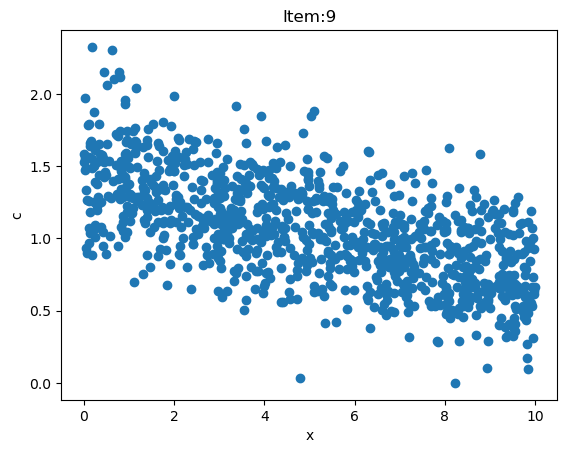

In [283]:
for item in range(len(c)):
    plot2D(x[0], c[item,], 'x', 'c', f'Item:{item}')

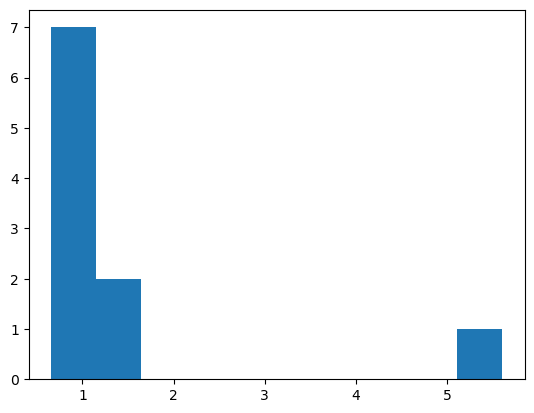

In [250]:
plt.hist(torch.mean(c, dim=1) / w)
plt.show()

In [272]:
#Split Data Into Train / Test
x_train, x_test, c_train, c_test = train_test_split(x.T, c.T, test_size= int(n *.9))

#Create Optimization Model Datasets, and Data Loaders
optmodel = pyepo.model.grb.knapsackModel(w.view(1, -1), capacity)
dataset_train = pyepo.data.dataset.optDataset(optmodel, x_train, c_train)
dataset_test = pyepo.data.dataset.optDataset(optmodel, x_test, c_test)

batch_size = 32
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

Set parameter Username
Set parameter LicenseID to value 2774727
Academic license - for non-commercial use only - expires 2027-02-03
Optimizing for optDataset...


100%|██████████| 100/100 [00:00<00:00, 449.59it/s]

Optimizing for optDataset...



100%|██████████| 900/900 [00:01<00:00, 660.98it/s]


In [273]:
#Define Models

#Linear Regression Model
class LinearRegression(nn.Module):
    def __init__(self):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(d, i)

    def forward(self, x):
        out = self.linear(x)
        return out

#MLP Model
class MLP(nn.Module):
    def __init__(self, num_feat, hidden, num_item):
        super(MLP, self).__init__()
        self.l1 = nn.Linear(num_feat, hidden)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden, num_item)
        
    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out

In [274]:
def trainModel(model, criterion, name, epochs=40, lr=1e-1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_loss_log, train_regret_log = [], []
    test_loss_log, test_regret_log = [], []
    
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        temp_loss = []
        for data in loader_train:
            x, c, w, z = data
            cp = model(x)
            
            loss = criterion(cp, c, w, z) if name == "SPO+" else criterion(cp, c)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            temp_loss.append(loss.item())

        # Calculate Training Metrics (Once per epoch)
        train_loss_log.append(np.mean(temp_loss))
        train_regret_log.append(pyepo.metric.regret(model, optmodel, loader_train))

        # --- TESTING ---
        model.eval() # Important for consistency
        temp_loss = []
        with torch.no_grad():
            for data in loader_test:
                x, c, w, z = data
                cp = model(x)
                loss = criterion(cp, c, w, z) if name == "SPO+" else criterion(cp, c)
                temp_loss.append(loss.item())
        
        # Calculate Testing Metrics (Once per epoch)
        test_loss_log.append(np.mean(temp_loss))
        test_regret_log.append(pyepo.metric.regret(model, optmodel, loader_test))

        if epoch % 10 == 0:
            print(f'Epoch:{epoch} Loss Type:{name}')
            print(f'Train Loss {train_loss_log[-1]:.2f} Test Loss {test_loss_log[-1]:.2f}')
            print(f'Train Regret {train_regret_log[-1] *100:.2f}% Test Regret {test_regret_log[-1]*100:.2f}%')

    return train_loss_log, test_loss_log, train_regret_log, test_regret_log

In [275]:
def plotLearningCurves(train_loss, test_loss, train_regret, test_regret, name):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    epochs = range(len(train_loss))

    # --- Plot 1: Loss (Prediction Error) ---
    ax[0].plot(epochs, train_loss, label='Train Loss', color='blue', lw=2)
    ax[0].plot(epochs, test_loss, label='Test Loss', color='lightblue', linestyle='--')
    ax[0].set_title(f'{name} Loss Trajectory')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss Value')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # --- Plot 2: Regret (Decision Error) ---
    # We multiply by 100 to show percentage
    ax[1].plot(epochs, [r * 100 for r in train_regret], label='Train Regret', color='green', lw=2)
    ax[1].plot(epochs, [r * 100 for r in test_regret], label='Test Regret', color='lightgreen', linestyle='--')
    ax[1].set_title(f'{name} Regret Trajectory')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Regret (%)')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Epoch:0 Loss Type:MSE
Train Loss 143.37 Test Loss 108.56
Train Regret 18.37% Test Regret 16.72%
Epoch:10 Loss Type:MSE
Train Loss 39.10 Test Loss 36.47
Train Regret 7.01% Test Regret 7.66%
Epoch:20 Loss Type:MSE
Train Loss 35.27 Test Loss 30.32
Train Regret 6.44% Test Regret 6.35%
Epoch:30 Loss Type:MSE
Train Loss 29.91 Test Loss 25.30
Train Regret 4.20% Test Regret 3.03%
Epoch:40 Loss Type:MSE
Train Loss 21.82 Test Loss 21.16
Train Regret 2.29% Test Regret 2.14%


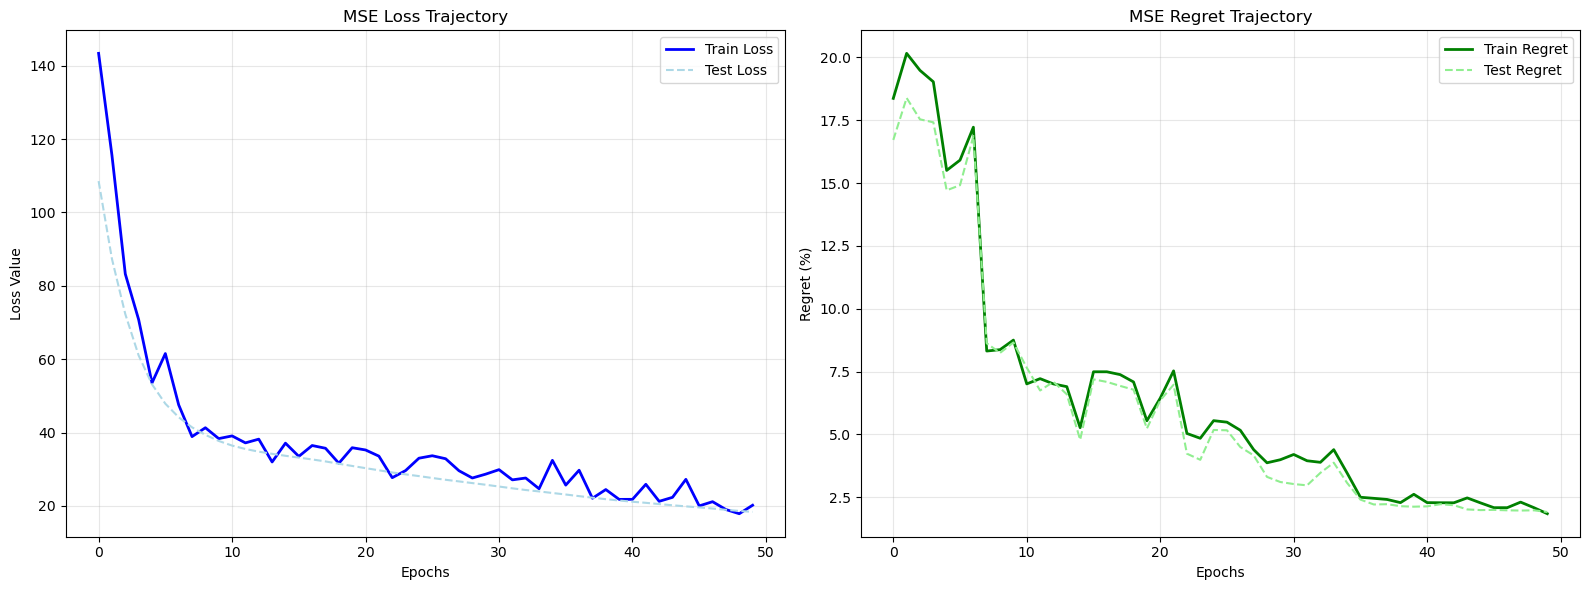

In [281]:
model_mse = LinearRegression()
mse = nn.MSELoss()
logs_mse = trainModel(model_mse, mse, "MSE", epochs=50)
plotLearningCurves(*logs_mse, name="MSE")

Num of cores: 1
Epoch:0 Loss Type:SPO+
Train Loss 53.17 Test Loss 39.84
Train Regret 29.93% Test Regret 31.25%
Epoch:10 Loss Type:SPO+
Train Loss 6.64 Test Loss 6.19
Train Regret 1.76% Test Regret 1.79%
Epoch:20 Loss Type:SPO+
Train Loss 5.33 Test Loss 3.56
Train Regret 1.65% Test Regret 1.16%
Epoch:30 Loss Type:SPO+
Train Loss 3.07 Test Loss 3.24
Train Regret 1.48% Test Regret 1.29%
Epoch:40 Loss Type:SPO+
Train Loss 3.31 Test Loss 3.10
Train Regret 2.11% Test Regret 1.40%


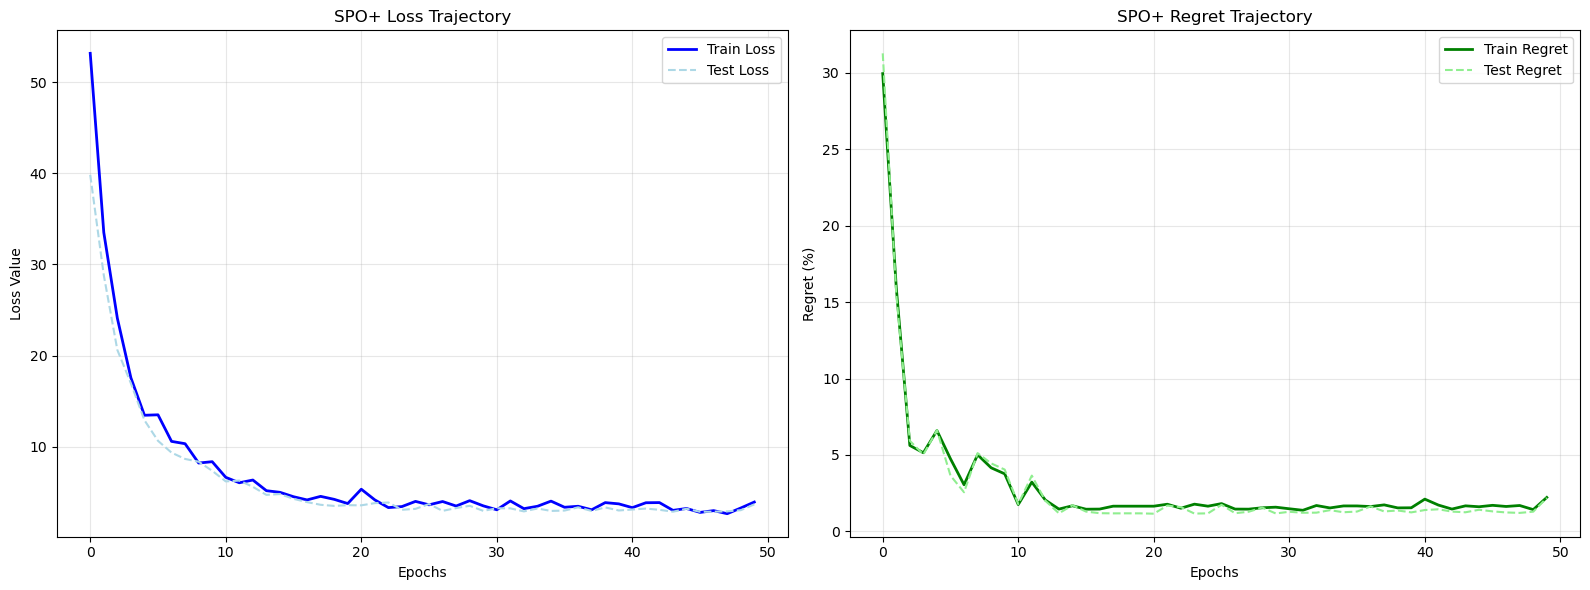

In [282]:
model_spo = LinearRegression()
spop = pyepo.func.SPOPlus(optmodel, processes=1)
logs_spo = trainModel(model_spo, spop, "SPO+", epochs=50)
plotLearningCurves(*logs_spo, name="SPO+")

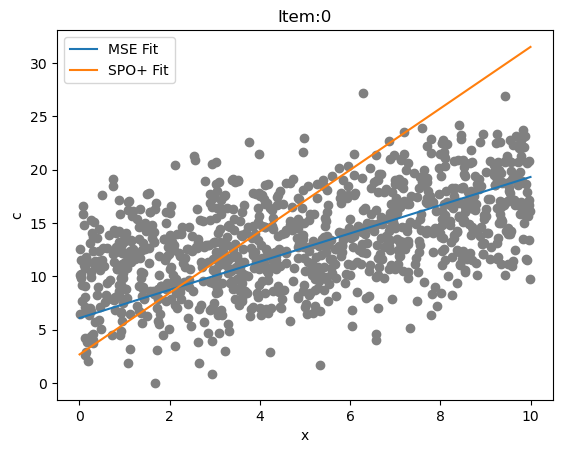

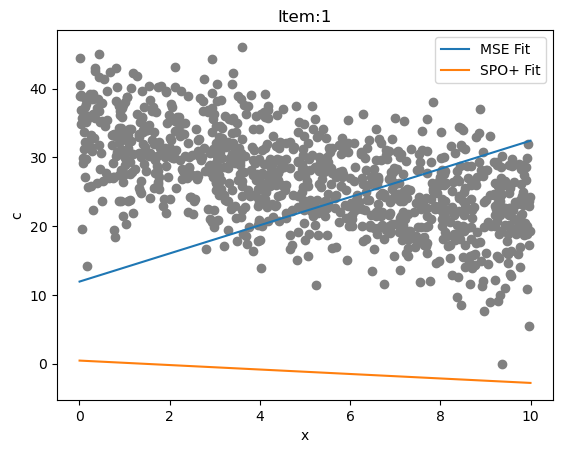

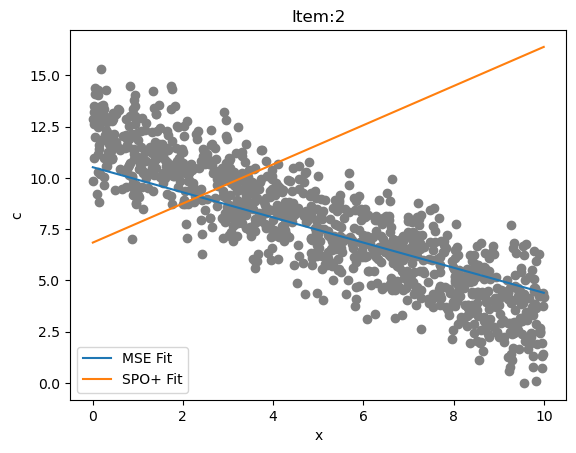

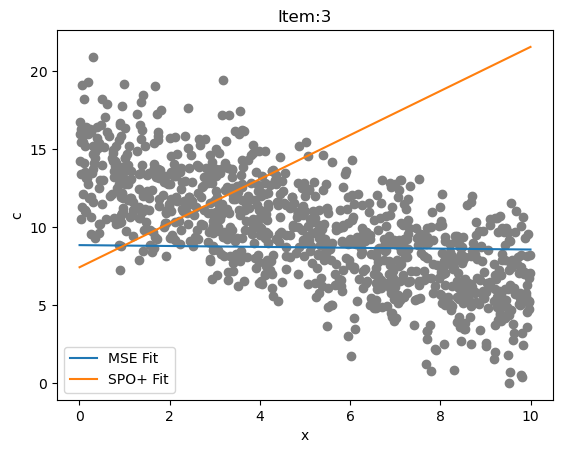

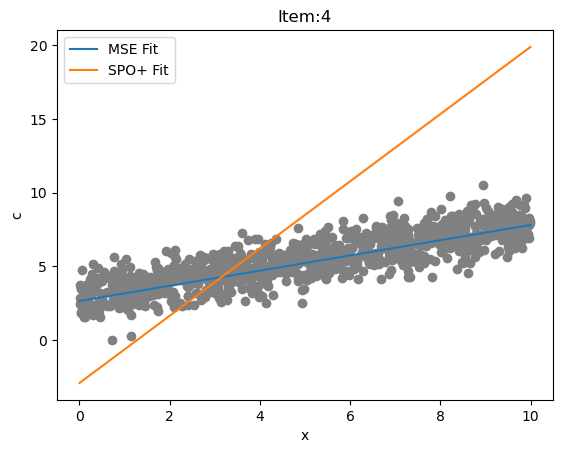

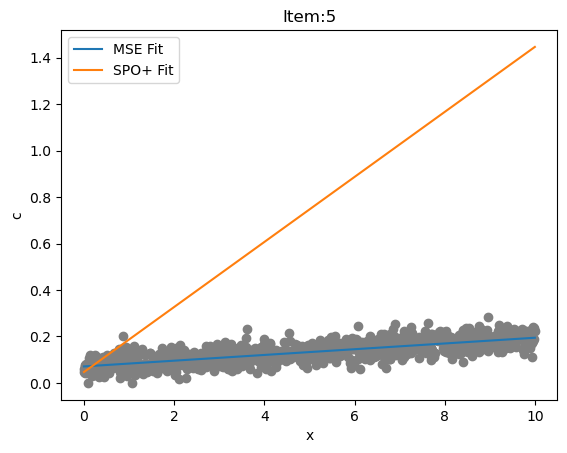

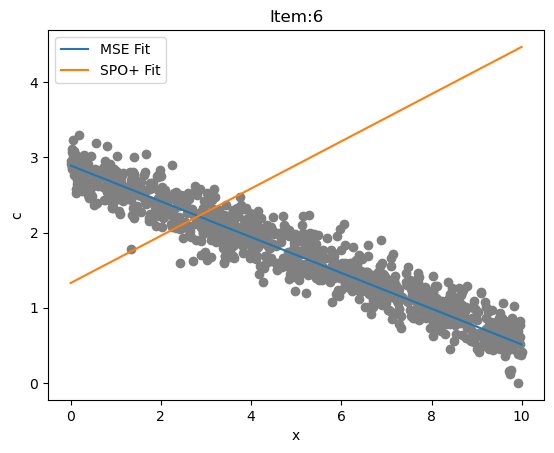

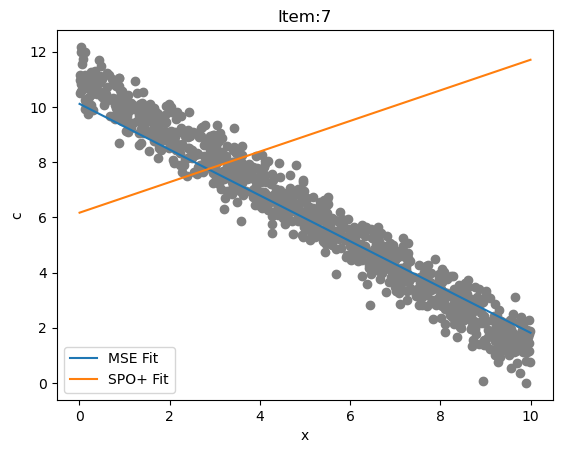

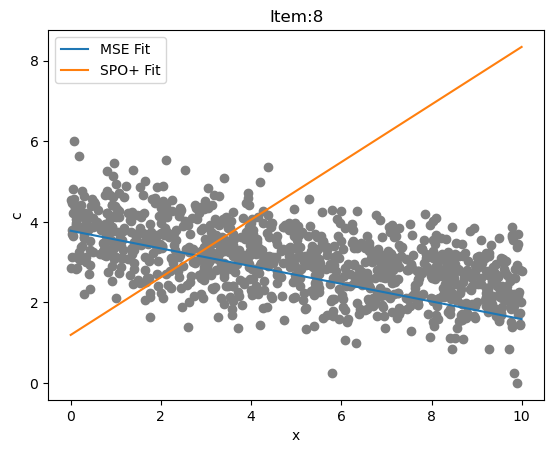

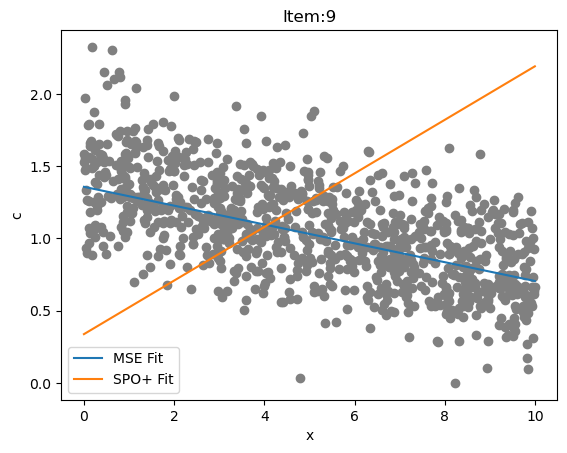

In [307]:
for item in range(len(c)):
    fits = [
    {'type' : 'MSE Fit', 'weights' : model_mse.linear.weight.detach()[item], 'bias' : model_mse.linear.bias.detach()[item]},
    {'type' : 'SPO+ Fit', 'weights' : model_spo.linear.weight.detach()[item], 'bias' : model_spo.linear.bias.detach()[item]},
    ]
    plot2D(x[0], c[item,], 'x', 'c', f'Item:{item}', fits)

In [322]:
labels = [f'Item {i}' for i in range(len(w))]
df = pd.DataFrame({
    "Items" : labels,
    "Weights" : w.tolist(),
    "Avg. Value" : torch.mean(c, dim = 1).tolist(),
    "Avg. Ratio" : (torch.mean(c, dim = 1) / w).tolist()
})
print(df.sort_values(by='Avg. Ratio', ascending=False))

    Items    Weights  Avg. Value  Avg. Ratio
0  Item 0  10.375858   13.452417    1.296511
3  Item 3  10.373637    9.804602    0.945146
2  Item 2   9.213055    7.646428    0.829956
7  Item 7   7.670870    6.113403    0.796963
1  Item 1  39.354858   26.966433    0.685212
8  Item 8   4.805241    3.041748    0.633006
6  Item 6   2.805485    1.706247    0.608183
4  Item 4   9.716812    5.461402    0.562057
9  Item 9   2.009251    1.068918    0.531998
5  Item 5   1.000000    0.134252    0.134252
